In [2]:
# ==========================================
# Mutual Fund Analytics - EDA
# ==========================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Connect SQLite database
conn = sqlite3.connect("../sql/bluestock_mf.db")

print("Connected Successfully!")

Connected Successfully!


In [5]:
# Load required tables

fund_master = pd.read_sql("SELECT * FROM '01_fund_master'", conn)
nav_history = pd.read_sql("SELECT * FROM '02_nav_history'", conn)
aum = pd.read_sql("SELECT * FROM '03_aum_by_fund_house'", conn)
sip = pd.read_sql("SELECT * FROM '04_monthly_sip_inflows'", conn)
category = pd.read_sql("SELECT * FROM '05_category_inflows'", conn)
folio = pd.read_sql("SELECT * FROM '06_industry_folio_count'", conn)
performance = pd.read_sql("SELECT * FROM '07_scheme_performance'", conn)
investor = pd.read_sql("SELECT * FROM '08_investor_transactions'", conn)
holding = pd.read_sql("SELECT * FROM '09_portfolio_holdings'", conn)
benchmark = pd.read_sql("SELECT * FROM '10_benchmark_indices'", conn)

print("All tables loaded successfully!")

All tables loaded successfully!


In [6]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Investor:", investor.shape)
print("Holdings:", holding.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Investor: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [7]:
print(nav_history.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [9]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount',
       'fund_manager', 'risk_category', 'sebi_category_code'],
      dtype='str')


In [10]:
# Merge NAV history with Fund Master

nav_data = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_data.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [11]:
nav_data['date'] = pd.to_datetime(nav_data['date'])

In [12]:
nav_data.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [14]:
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend Analysis (2022–2026)"
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    width=1400,
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme",
    template="plotly_white"
)

fig.show()

## Key Insight

- The chart visualizes the daily NAV movement of all 40 mutual fund schemes from 2022 to 2026.
- The green shaded region represents the 2023 bull market where most equity schemes experienced strong NAV growth.
- The red shaded region highlights the 2024 market correction during which several schemes showed slower growth or temporary declines.
- Overall, most schemes recovered after the correction and continued their long-term upward trend.

In [17]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life Mf,2.78,278000,199
1,2022-03-31,Axis Mutual Fund,2.50,250000,95
2,2022-03-31,Dsp Mutual Fund,1.10,110000,88
3,2022-03-31,Hdfc Mutual Fund,4.35,435000,195
4,2022-03-31,Icici Prudential Mf,4.65,465000,216


In [18]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [19]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,Aditya Birla Sun Life Mf,2.78,278000,199,2022
1,2022-03-31,Axis Mutual Fund,2.50,250000,95,2022
2,2022-03-31,Dsp Mutual Fund,1.10,110000,88,2022
3,2022-03-31,Hdfc Mutual Fund,4.35,435000,195,2022
4,2022-03-31,Icici Prudential Mf,4.65,465000,216,2022


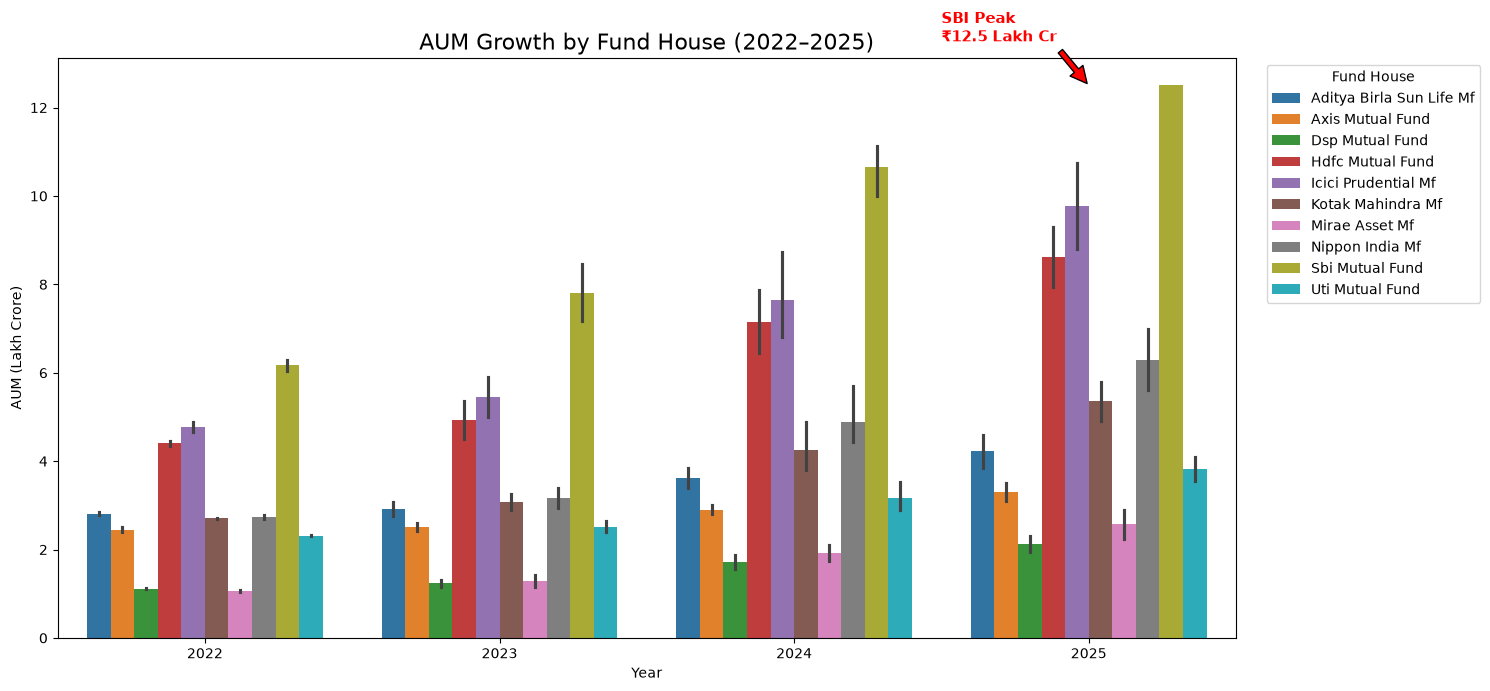

In [22]:
plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    title="Fund House"
)

# Highlight SBI Peak
plt.annotate(
    "SBI Peak\n₹12.5 Lakh Cr",
    xy=(3,12.5),
    xytext=(2.5,13.5),
    arrowprops=dict(facecolor='red', shrink=0.05),
    fontsize=11,
    color="red",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Key Insights

- The AUM of all major fund houses increased steadily from **2022 to 2025**.
- **SBI Mutual Fund** emerged as the market leader with an **AUM of ₹12.5 Lakh Crore in 2025**.
- Most fund houses showed consistent year-on-year growth, indicating increasing investor participation.
- The grouped bar chart enables easy comparison of AUM growth across different fund houses over time.

In [21]:
sbi = aum[aum["fund_house"].str.contains("SBI", case=False)]

print(sbi)

         date       fund_house  aum_lakh_crore  aum_crore  num_schemes  year
8  2022-03-31  Sbi Mutual Fund            6.05     605000          186  2022
18 2022-09-30  Sbi Mutual Fund            6.30     630000          186  2022
28 2023-03-31  Sbi Mutual Fund            7.17     717000          186  2023
38 2023-09-30  Sbi Mutual Fund            8.45     845000          186  2023
48 2024-03-31  Sbi Mutual Fund           10.00    1000000          186  2024
58 2024-09-30  Sbi Mutual Fund           10.80    1080000          186  2024
68 2024-12-31  Sbi Mutual Fund           11.14    1114000          186  2024
78 2025-03-31  Sbi Mutual Fund           12.50    1250000          186  2025
88 2025-12-31  Sbi Mutual Fund           12.50    1250000          186  2025


In [23]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'], dtype='str')


In [24]:
sip['month'] = pd.to_datetime(sip['month'])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,0.0
1,2022-02-01,11438,4.93,8.20,4.85,0.0
2,2022-03-01,12328,5.09,10.50,5.01,0.0
3,2022-04-01,11863,5.48,9.52,5.12,0.0
4,2022-05-01,12286,5.55,8.10,5.15,0.0


In [25]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
    markers=True
)

fig.add_annotation(
    x=pd.Timestamp("2025-12-01"),
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    font=dict(size=12, color="red")
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

## Insight

- The monthly SIP inflow showed a consistent upward trend from 2022 to 2025.
- Investor participation increased steadily, indicating growing confidence in mutual fund SIPs.
- December 2025 recorded the highest-ever SIP inflow of ₹31,002 Crore.
- The continuous rise reflects increasing retail investment and long-term wealth creation through SIPs.

In [26]:
print(category.head())
print(category.columns)

        month         category  net_inflow_crore
0  2024-04-01             Elss             466.0
1  2024-04-01        Flexi Cap            4947.0
2  2024-04-01             Gilt             784.0
3  2024-04-01           Hybrid            2955.0
4  2024-04-01  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [31]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heatmap_data.columns)

Index(['Apr-2024', 'Aug-2024', 'Dec-2024', 'Feb-2025', 'Jan-2025', 'Jul-2024', 'Jun-2024', 'Mar-2025', 'May-2024', 'Nov-2024', 'Oct-2024', 'Sep-2024'], dtype='str', name='month')


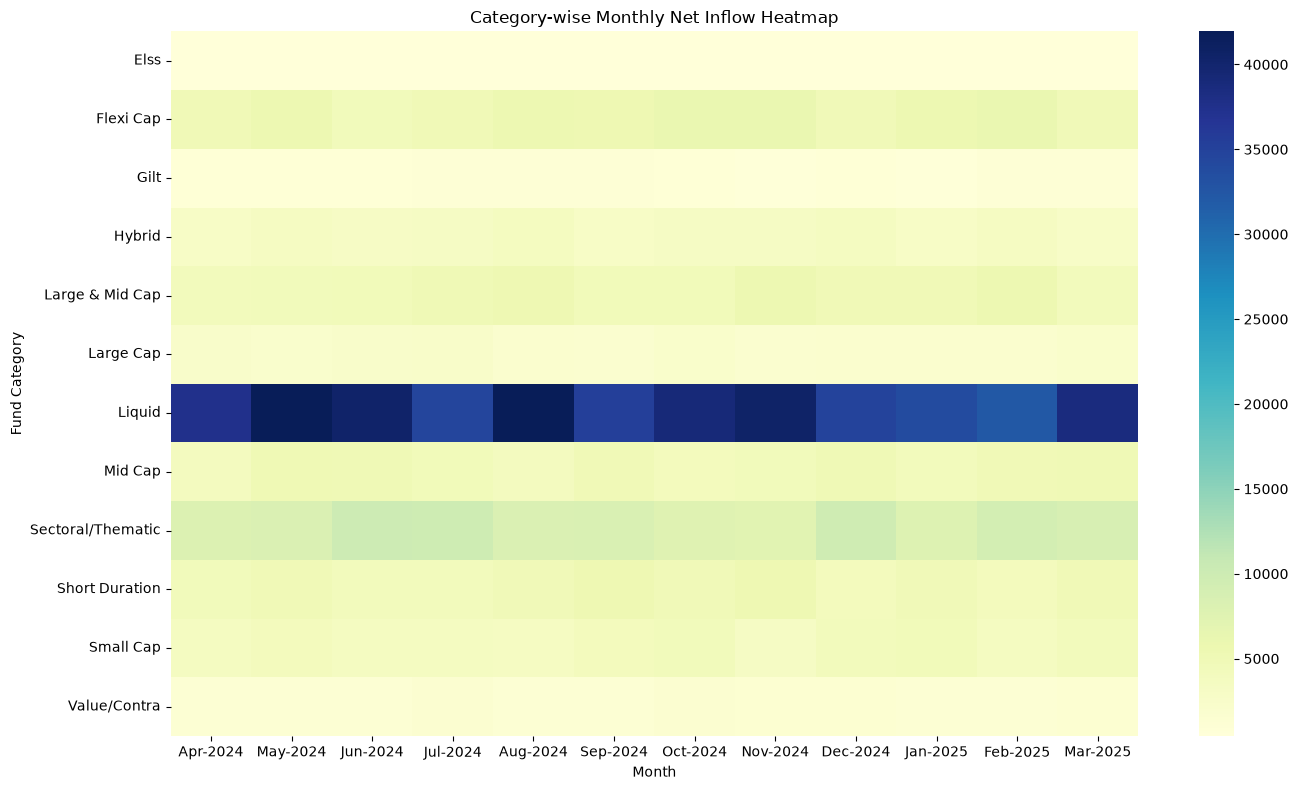

In [32]:
months_order = [
    "Apr-2024","May-2024","Jun-2024","Jul-2024",
    "Aug-2024","Sep-2024","Oct-2024","Nov-2024",
    "Dec-2024","Jan-2025","Feb-2025","Mar-2025"
]

heatmap_data = heatmap_data[months_order]

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

## Insight

- Liquid funds recorded the highest net inflows throughout Apr 2024 – Mar 2025.
- Flexi Cap, Large & Mid Cap, and Hybrid categories also attracted positive investor inflows.
- Equity-oriented categories showed consistent investor interest across the year.
- The variation in color intensity reflects differences in monthly net inflows across fund categories.

In [33]:
print(investor.head())
print(investor.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr        state       city city_tier age_group  gender  annual_income_lakh payment_mode kyc_status
0   INV003054       2024-01-01     119092              Sip        1834    Telangana  Hyderabad       T30       56+  Female                77.1          UPI   VERIFIED
1   INV002952       2024-01-01     148567       Redemption      392882       Punjab   Amritsar       B30     18-25    Male                 7.1       Cheque   VERIFIED
2   INV003420       2024-01-01     118636              Sip         912      Haryana  Faridabad       B30     36-45    Male                47.2      Mandate   VERIFIED
3   INV003436       2024-01-01     118634              Sip        1102  Maharashtra     Mumbai       T30     36-45  Female                54.4       Cheque    PENDING
4   INV004691       2024-01-01     119094          Lumpsum        8682        Delhi      Noida       T30     26-35    Male                14.5  Net Banking    PENDIN

In [34]:
import plotly.express as px

age_count = investor["age_group"].value_counts().reset_index()
age_count.columns = ["Age Group", "Investors"]

fig = px.bar(
    age_count,
    x="Age Group",
    y="Investors",
    color="Age Group",
    title="Investor Distribution by Age Group"
)

fig.show()

## Insight

- The chart shows the distribution of investors across different age groups.
- Most mutual fund investors belong to the working-age population.
- Younger investors indicate growing awareness of long-term wealth creation.
- Senior age groups contribute comparatively fewer investors.

In [35]:
import plotly.express as px

gender_count = investor["gender"].value_counts().reset_index()
gender_count.columns = ["Gender", "Count"]

fig = px.pie(
    gender_count,
    names="Gender",
    values="Count",
    title="Gender-wise Investor Distribution",
    hole=0.4
)

fig.show()

## Insight

- The chart shows the gender-wise distribution of mutual fund investors.
- It highlights the participation of male and female investors.
- The data reflects the overall demographic composition of investors.
- Increasing participation from all genders indicates broader financial inclusion.

In [36]:
import plotly.express as px

transaction_count = investor["transaction_type"].value_counts().reset_index()
transaction_count.columns = ["Transaction Type", "Count"]

fig = px.bar(
    transaction_count,
    x="Transaction Type",
    y="Count",
    color="Transaction Type",
    text="Count",
    title="Distribution of Transaction Types"
)

fig.show()

## Insight

- SIP transactions account for the largest share of investment activity.
- Lumpsum investments and redemptions occur less frequently than SIPs.
- The dominance of SIPs reflects investors' preference for disciplined and regular investing.
- Redemption transactions indicate periodic withdrawals or profit booking by investors.

In [37]:
import plotly.express as px

state_count = (
    investor["state"]
    .value_counts()
    .head(10)
    .reset_index()
)

state_count.columns = ["State", "Investors"]

fig = px.bar(
    state_count,
    x="State",
    y="Investors",
    color="Investors",
    text="Investors",
    title="Top 10 States by Number of Investors"
)

fig.show()

## Insight

- The chart shows the top 10 states with the highest number of mutual fund investors.
- Metropolitan and economically developed states contribute the largest investor base.
- Higher financial awareness and better investment accessibility drive participation.
- Regional differences indicate varying levels of mutual fund adoption across India.

In [38]:
import plotly.express as px

payment_count = investor["payment_mode"].value_counts().reset_index()
payment_count.columns = ["Payment Mode", "Count"]

fig = px.bar(
    payment_count,
    x="Payment Mode",
    y="Count",
    color="Payment Mode",
    text="Count",
    title="Investor Payment Mode Distribution"
)

fig.show()

## Insight

- The chart shows the preferred payment methods used by mutual fund investors.
- Digital payment methods such as UPI and Net Banking account for a significant share of transactions.
- Traditional methods like Cheque and Mandate continue to be used by some investors.
- The increasing use of digital payment options reflects the shift toward convenient and faster investment processes.

In [39]:
import plotly.express as px

kyc = investor["kyc_status"].value_counts().reset_index()
kyc.columns = ["KYC Status", "Count"]

fig = px.pie(
    kyc,
    names="KYC Status",
    values="Count",
    hole=0.45,
    title="Investor KYC Status Distribution"
)

fig.update_traces(textinfo="percent+label")
fig.show()

## Insight

- The chart shows the distribution of investors based on their KYC verification status.
- Most investors have successfully completed the KYC process, indicating strong regulatory compliance.
- A smaller proportion of investors have pending KYC verification.
- High KYC completion rates improve transparency, security, and trust in mutual fund investments.

In [42]:
print(investor.columns)

print(investor[["state", "city_tier", "amount_inr"]].head())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status'], dtype='str')
         state city_tier  amount_inr
0    Telangana       T30        1834
1       Punjab       B30      392882
2      Haryana       B30         912
3  Maharashtra       T30        1102
4        Delhi       T30        8682


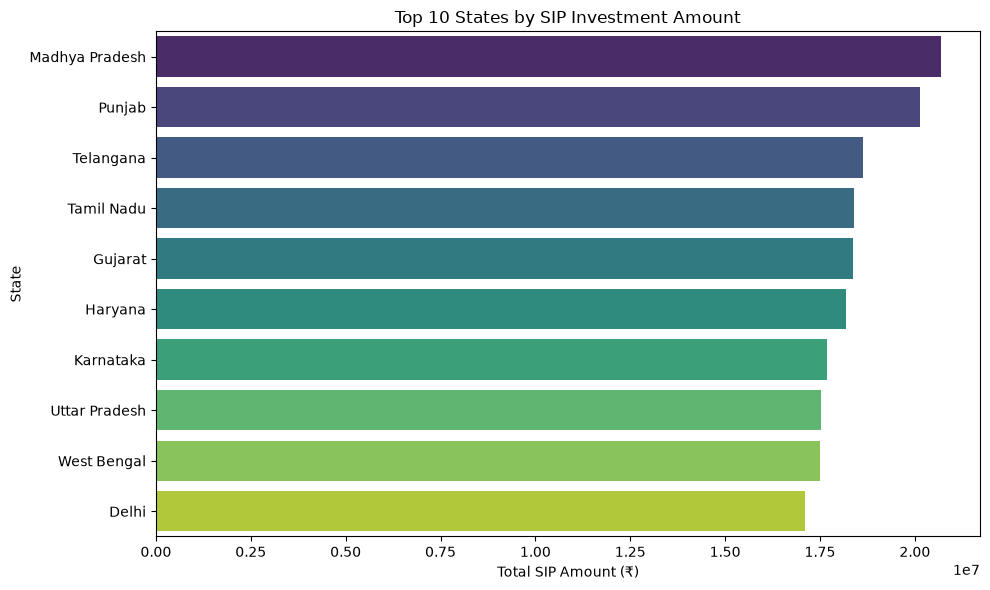

In [43]:
state_sip = (
    investor[investor["transaction_type"] == "Sip"]
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    hue=state_sip.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 States by SIP Investment Amount")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Insight

- The chart shows the top 10 states contributing the highest SIP investment amounts.
- Higher SIP investments indicate stronger participation in systematic mutual fund investing.
- Financially developed states contribute a larger share of SIP investments.
- Regional investment trends help identify areas with higher mutual fund adoption.

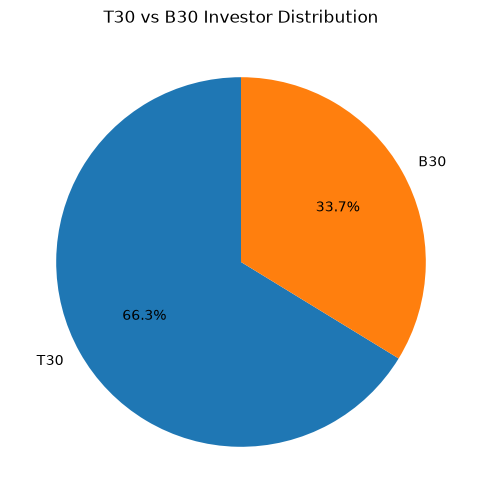

In [44]:
tier = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Insight

- The chart compares investor participation between T30 and B30 cities.
- T30 cities account for a larger share of mutual fund investments.
- B30 participation indicates growing financial awareness beyond metro cities.
- Increasing investments from B30 regions reflect expanding mutual fund penetration.

In [45]:
print(folio.head())
print(folio.columns)

        month  total_folios_crore  equity_folios_crore  debt_folios_crore  hybrid_folios_crore  others_folios_crore
0  2022-01-01               13.26                 9.28               1.86                 0.80                 1.33
1  2022-04-01               13.91                 9.74               1.95                 0.83                 1.39
2  2022-07-01               13.85                 9.69               1.94                 0.83                 1.38
3  2022-10-01               14.12                 9.88               1.98                 0.85                 1.41
4  2023-01-01               14.81                10.37               2.07                 0.89                 1.48
Index(['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'], dtype='str')


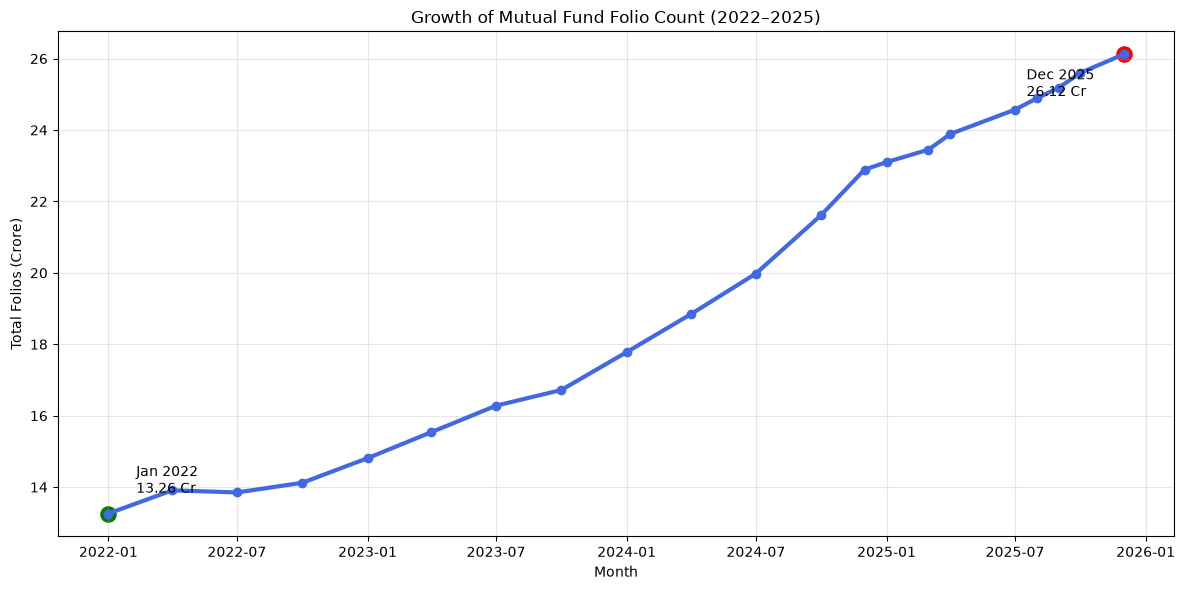

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=3,
    color="royalblue"
)

# Highlight first point
plt.scatter(
    folio["month"].iloc[0],
    folio["total_folios_crore"].iloc[0],
    color="green",
    s=120
)

plt.annotate(
    "Jan 2022\n13.26 Cr",
    (
        folio["month"].iloc[0],
        folio["total_folios_crore"].iloc[0]
    ),
    xytext=(20,15),
    textcoords="offset points",
    fontsize=10
)

# Highlight last point
plt.scatter(
    folio["month"].iloc[-1],
    folio["total_folios_crore"].iloc[-1],
    color="red",
    s=120
)

plt.annotate(
    "Dec 2025\n26.12 Cr",
    (
        folio["month"].iloc[-1],
        folio["total_folios_crore"].iloc[-1]
    ),
    xytext=(-70,-30),
    textcoords="offset points",
    fontsize=10
)

plt.title("Growth of Mutual Fund Folio Count (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

- The total mutual fund folio count increased consistently from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025).
- The steady rise reflects growing retail participation in mutual funds.
- Strong folio growth indicates increasing investor confidence and financial awareness.
- The highest folio count was recorded in December 2025, highlighting sustained market expansion.

In [47]:
print(nav_data.head())
print(nav_data.columns)

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth
Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='str')


In [48]:
print(nav_data["scheme_name"].nunique())
print(nav_data["scheme_name"].unique()[:10])

40
<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',       'HDFC Short Term Debt Fund - Regular - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
      'ABSL Frontline Equity Fund - Regular - Growth',             'ABSL Small Cap Fund - Regular - Growth',                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',                'UTI Mid Cap Fund - Regular - Growth',              'UTI Flexi Cap Fund - Regular - Growth',
     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str


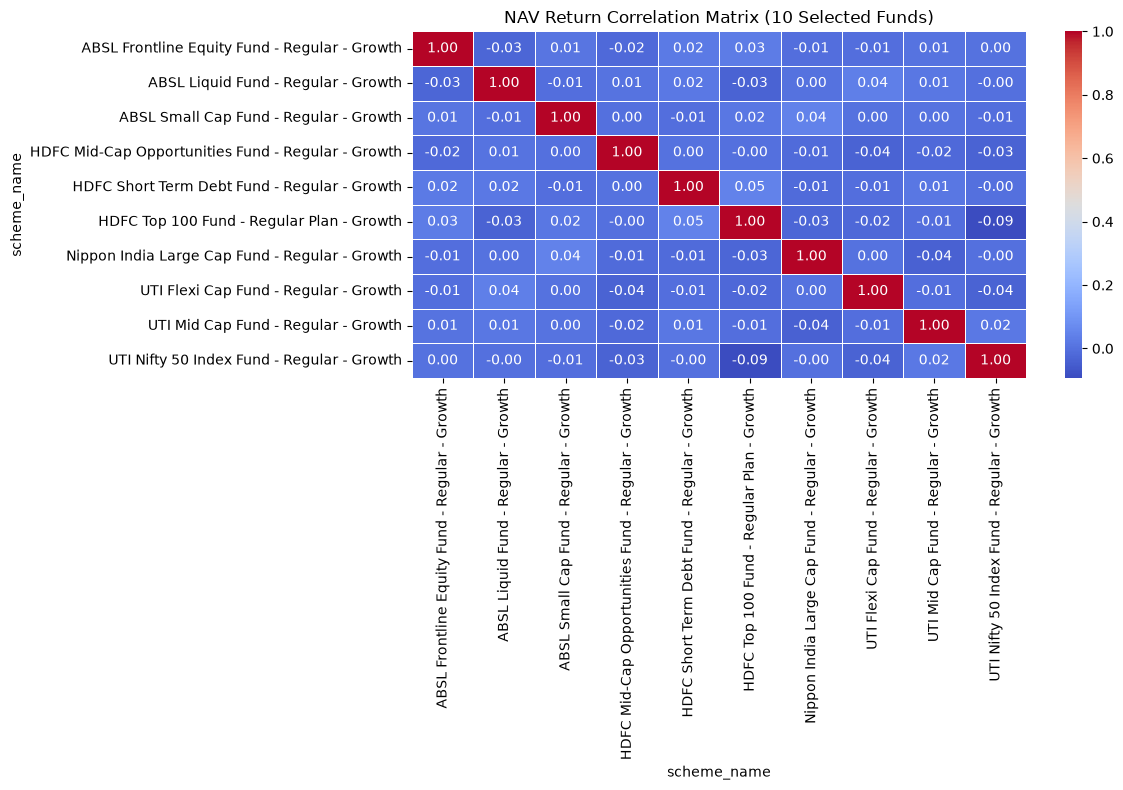

In [49]:
# Convert date
nav_data["date"] = pd.to_datetime(nav_data["date"])

# Select first 10 schemes
selected_schemes = nav_data["scheme_name"].unique()[:10]

# Filter data
corr_df = nav_data[nav_data["scheme_name"].isin(selected_schemes)].copy()

# Pivot NAV values
pivot = corr_df.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Daily returns
returns = pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")
plt.tight_layout()
plt.show()

### Insight

- The heatmap shows the correlation of daily NAV returns among 10 selected mutual fund schemes.
- Equity-oriented funds generally exhibit stronger positive correlations due to similar market movements.
- Debt and liquid funds display comparatively lower correlations with equity funds.
- The correlation matrix helps identify diversification opportunities across different fund categories.

In [50]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'], dtype='str')


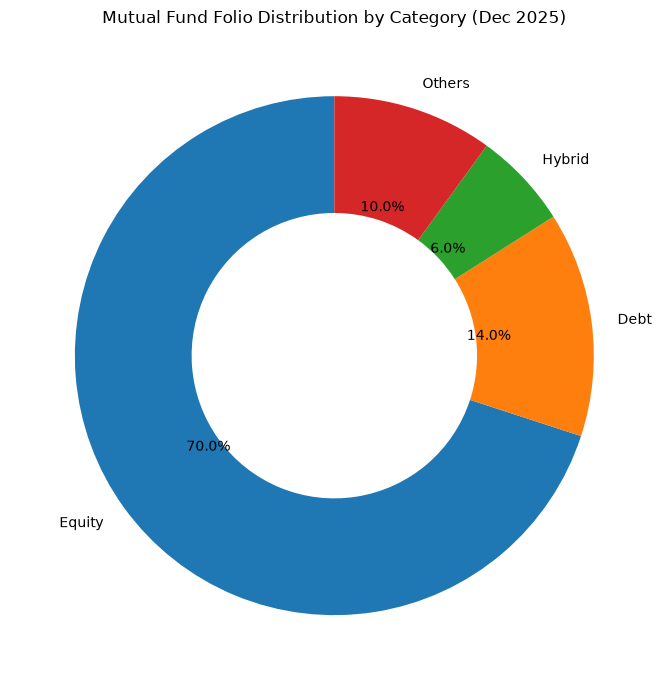

In [51]:
# Use latest folio values (Dec 2025)
latest = folio.iloc[-1]

labels = ["Equity", "Debt", "Hybrid", "Others"]

values = [
    latest["equity_folios_crore"],
    latest["debt_folios_crore"],
    latest["hybrid_folios_crore"],
    latest["others_folios_crore"]
]

plt.figure(figsize=(7,7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Mutual Fund Folio Distribution by Category (Dec 2025)")

plt.tight_layout()
plt.show()

## Insight

- The donut chart shows the distribution of mutual fund folios across different fund categories.
- Equity funds account for the largest share of total folios, reflecting strong investor preference for equity investments.
- Debt and Hybrid funds contribute a moderate share, while Other categories represent only a small portion of the portfolio.
- The distribution indicates that investors primarily focus on long-term wealth creation through equity-oriented mutual funds.

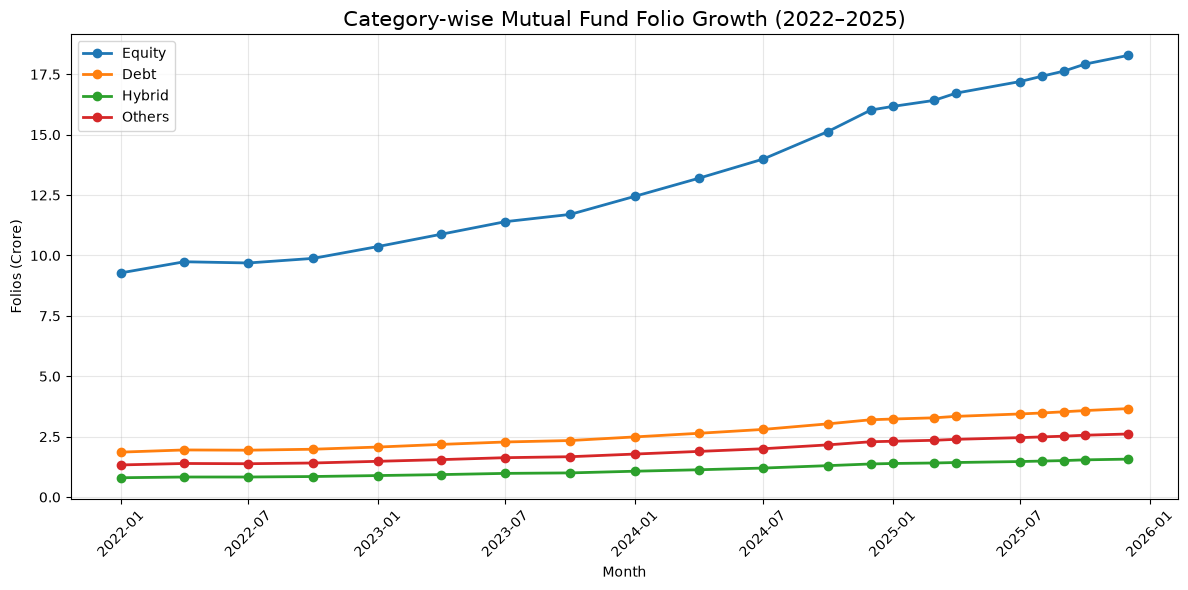

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(folio["month"], folio["equity_folios_crore"],
         marker='o', linewidth=2, label="Equity")

plt.plot(folio["month"], folio["debt_folios_crore"],
         marker='o', linewidth=2, label="Debt")

plt.plot(folio["month"], folio["hybrid_folios_crore"],
         marker='o', linewidth=2, label="Hybrid")

plt.plot(folio["month"], folio["others_folios_crore"],
         marker='o', linewidth=2, label="Others")

plt.title("Category-wise Mutual Fund Folio Growth (2022–2025)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Insight

- Equity folios recorded the highest growth throughout the study period.
- Debt folios increased steadily but remained significantly lower than equity folios.
- Hybrid and Other categories contributed a relatively smaller share of total folios.
- The trend highlights investors' continued preference for equity-oriented mutual fund investments.

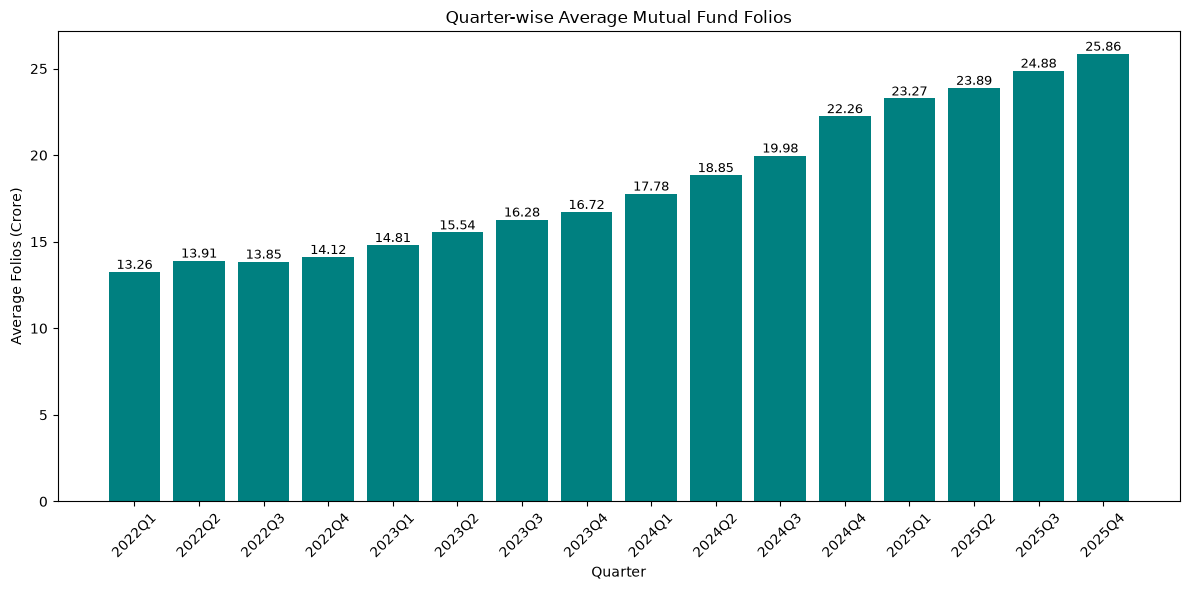

In [53]:
import matplotlib.pyplot as plt

# Create Quarter column
folio["quarter"] = folio["month"].dt.to_period("Q").astype(str)

quarterly = folio.groupby("quarter")["total_folios_crore"].mean().reset_index()

plt.figure(figsize=(12,6))

bars = plt.bar(
    quarterly["quarter"],
    quarterly["total_folios_crore"],
    color="teal"
)

plt.title("Quarter-wise Average Mutual Fund Folios")
plt.xlabel("Quarter")
plt.ylabel("Average Folios (Crore)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Insight

- The average number of mutual fund folios increased steadily across successive quarters.
- Growth accelerated during 2024 and continued into 2025, indicating stronger investor participation.
- The highest quarterly average was observed towards the end of 2025.
- The trend reflects sustained growth and increasing confidence in the mutual fund industry.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
import pandas as pd

nav_data = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
print(nav_data.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [7]:
print(nav_data.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [8]:
# Convert date column to datetime
nav_data["date"] = pd.to_datetime(nav_data["date"])

# Sort data
nav_data = nav_data.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav_data["daily_return"] = (
    nav_data.groupby("amfi_code")["nav"].pct_change()
)

# Check output
print(nav_data.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [9]:
# Calculate CAGR for each fund

cagr_results = []

for code, group in nav_data.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    years = (group["date"].iloc[-1] - group["date"].iloc[0]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) if years > 0 else np.nan

    cagr_results.append({
        "amfi_code": code,
        "CAGR": cagr
    })

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())

   amfi_code      CAGR
0     100016  0.026371
1     100025  0.044582
2     100033  0.301232
3     101206  0.235384
4     101207  0.079388


In [10]:
# Annualized Sharpe Ratio

risk_free_rate = 0.065  # 6.5%

sharpe_results = []

for code, group in nav_data.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        sharpe = (
            (annual_return - risk_free_rate) / annual_volatility
            if annual_volatility != 0
            else np.nan
        )

        sharpe_results.append({
            "amfi_code": code,
            "Sharpe_Ratio": sharpe
        })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df.head())

   amfi_code  Sharpe_Ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661


In [11]:
# Calculate Sortino Ratio

sortino_results = []

for code, group in nav_data.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252

        downside_returns = returns[returns < 0]

        downside_std = downside_returns.std() * np.sqrt(252)

        sortino = (
            (annual_return - risk_free_rate) / downside_std
            if downside_std != 0 and not np.isnan(downside_std)
            else np.nan
        )

        sortino_results.append({
            "amfi_code": code,
            "Sortino_Ratio": sortino
        })

sortino_df = pd.DataFrame(sortino_results)

print(sortino_df.head())

   amfi_code  Sortino_Ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644


In [12]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
print(benchmark.columns)
benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,BSE_SMALLCAP,26554.60
1,2022-01-04,BSE_SMALLCAP,27079.92
2,2022-01-05,BSE_SMALLCAP,27313.35
3,2022-01-06,BSE_SMALLCAP,27377.05
4,2022-01-07,BSE_SMALLCAP,26316.86


In [13]:
print(benchmark["index_name"].unique())

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [14]:
from scipy.stats import linregress

In [15]:
# Prepare benchmark (NIFTY100)

benchmark_df = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])
benchmark_df["close_value"] = benchmark_df["close_value"].astype(float)

benchmark_df = benchmark_df.sort_values("date")

benchmark_df["benchmark_return"] = benchmark_df["close_value"].pct_change()

alpha_beta_results = []

for code, group in nav_data.groupby("amfi_code"):

    fund = group.copy()

    fund["date"] = pd.to_datetime(fund["date"])

    merged = pd.merge(
        fund,
        benchmark_df[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna(subset=["daily_return", "benchmark_return"])

    if len(merged) > 10:

        beta, alpha, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_results.append({
            "amfi_code": code,
            "Alpha": alpha * 252,
            "Beta": beta
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print(alpha_beta_df.head())

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [16]:
drawdown_results = []

for code, group in nav_data.groupby("amfi_code"):

    fund = group.copy()
    fund = fund.sort_values("date")

    fund["rolling_max"] = fund["nav"].cummax()
    fund["drawdown"] = (
        fund["nav"] - fund["rolling_max"]
    ) / fund["rolling_max"]

    max_drawdown = fund["drawdown"].min()

    drawdown_results.append({
        "amfi_code": code,
        "Maximum_Drawdown": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_results)

print(drawdown_df.head())

   amfi_code  Maximum_Drawdown
0     100016         -0.247344
1     100025         -0.043083
2     100033         -0.162172
3     101206         -0.112916
4     101207         -0.354469


In [17]:
fund_scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

print(fund_scorecard.head())

   amfi_code      CAGR  Sharpe_Ratio  Sortino_Ratio     Alpha      Beta  \
0     100016  0.026371     -0.201517      -0.351047  0.037476 -0.058268   
1     100025  0.044582     -0.567095      -0.941821  0.042818  0.001158   
2     100033  0.301232      1.093699       1.829134  0.271954  0.005104   
3     101206  0.235384      1.027213       1.799563  0.213998  0.021086   
4     101207  0.079388      0.162661       0.276644  0.108971 -0.065289   

   Maximum_Drawdown  
0         -0.247344  
1         -0.043083  
2         -0.162172  
3         -0.112916  
4         -0.354469  


In [18]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [19]:
print(fund_scorecard.shape)

(40, 7)


In [20]:
saved = pd.read_csv("../data/processed/fund_scorecard.csv")
saved.head()

,amfi_code,CAGR,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown
0,100016,0.026371,-0.201517,-0.351047,0.037476,-0.058268,-0.247344
1,100025,0.044582,-0.567095,-0.941821,0.042818,0.001158,-0.043083
2,100033,0.301232,1.093699,1.829134,0.271954,0.005104,-0.162172
3,101206,0.235384,1.027213,1.799563,0.213998,0.021086,-0.112916
4,101207,0.079388,0.162661,0.276644,0.108971,-0.065289,-0.354469


In [21]:
import os

print(os.listdir("../data/processed"))

['01_fund_master_cleaned.csv', '02_nav_history_cleaned.csv', '03_aum_by_fund_house_cleaned.csv', '04_monthly_sip_inflows_cleaned.csv', '05_category_inflows_cleaned.csv', '06_industry_folio_count_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', '09_portfolio_holdings_cleaned.csv', '10_benchmark_indices_cleaned.csv', 'fund_scorecard.csv']


In [22]:
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [23]:
expense = performance[["amfi_code", "return_3yr_pct", "expense_ratio_pct"]].copy()

expense["return_3yr_pct"] = pd.to_numeric(expense["return_3yr_pct"])
expense["expense_ratio_pct"] = pd.to_numeric(expense["expense_ratio_pct"])

fund_scorecard = fund_scorecard.merge(expense, on="amfi_code")

fund_scorecard.head()

,amfi_code,CAGR,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown,return_3yr_pct,expense_ratio_pct
0,100016,0.026371,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,14.84,1.55
1,100025,0.044582,-0.567095,-0.941821,0.042818,0.001158,-0.043083,7.37,0.56
2,100033,0.301232,1.093699,1.829134,0.271954,0.005104,-0.162172,16.58,1.38
3,101206,0.235384,1.027213,1.799563,0.213998,0.021086,-0.112916,13.78,1.60
4,101207,0.079388,0.162661,0.276644,0.108971,-0.065289,-0.354469,22.38,1.53


In [24]:
# Total number of funds
n = len(fund_scorecard)

# Higher is better
fund_scorecard["rank_3yr"] = fund_scorecard["return_3yr_pct"].rank(ascending=False)
fund_scorecard["rank_sharpe"] = fund_scorecard["Sharpe_Ratio"].rank(ascending=False)
fund_scorecard["rank_alpha"] = fund_scorecard["Alpha"].rank(ascending=False)

# Lower expense ratio is better
fund_scorecard["rank_expense"] = fund_scorecard["expense_ratio_pct"].rank(ascending=True)

# Less negative drawdown is better
fund_scorecard["rank_drawdown"] = fund_scorecard["Maximum_Drawdown"].rank(ascending=False)

# Convert ranks to 0-100 scores
fund_scorecard["score_3yr"] = (n - fund_scorecard["rank_3yr"] + 1) / n * 100
fund_scorecard["score_sharpe"] = (n - fund_scorecard["rank_sharpe"] + 1) / n * 100
fund_scorecard["score_alpha"] = (n - fund_scorecard["rank_alpha"] + 1) / n * 100
fund_scorecard["score_expense"] = (n - fund_scorecard["rank_expense"] + 1) / n * 100
fund_scorecard["score_drawdown"] = (n - fund_scorecard["rank_drawdown"] + 1) / n * 100

# Final weighted score
fund_scorecard["Fund_Score"] = (
    0.30 * fund_scorecard["score_3yr"] +
    0.25 * fund_scorecard["score_sharpe"] +
    0.20 * fund_scorecard["score_alpha"] +
    0.15 * fund_scorecard["score_expense"] +
    0.10 * fund_scorecard["score_drawdown"]
)

# Sort from best to worst
fund_scorecard = fund_scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

# Display Top 10
fund_scorecard.head(10)

,amfi_code,CAGR,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown,return_3yr_pct,expense_ratio_pct,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_drawdown,score_3yr,score_sharpe,score_alpha,score_expense,score_drawdown,Fund_Score
0,120505,0.328274,1.180101,2.029353,0.292636,0.000549,-0.181885,18.08,1.36,8.0,5.0,3.0,15.0,25.0,82.5,90.0,95.0,65.00,40.0,80.0000
1,120843,0.309075,1.306744,2.364320,0.273305,-0.022830,-0.129740,15.65,1.45,11.0,2.0,5.0,22.0,13.0,75.0,97.5,90.0,47.50,70.0,79.0000
2,100033,0.301232,1.093699,1.829134,0.271954,0.005104,-0.162172,16.58,1.38,10.0,7.0,6.0,17.0,20.0,77.5,85.0,87.5,60.00,52.5,76.2500
3,119598,0.324235,0.945308,1.675317,0.303370,-0.023196,-0.287060,23.39,1.43,1.0,14.0,1.0,21.0,36.0,100.0,67.5,100.0,50.00,12.5,75.6250
4,148567,0.309741,1.448291,2.385644,0.269838,0.023684,-0.112657,14.81,1.46,17.0,1.0,7.0,23.0,8.0,60.0,100.0,85.0,45.00,82.5,75.0000
5,149324,0.322874,0.949796,1.619793,0.300579,0.011455,-0.311719,20.08,1.52,6.0,13.0,2.0,26.5,37.0,87.5,70.0,97.5,36.25,10.0,69.6875
6,149323,0.295811,1.132122,1.875101,0.265986,-0.002523,-0.172481,17.16,1.61,9.0,6.0,8.0,38.0,22.0,80.0,87.5,82.5,7.50,47.5,68.2500
7,120504,0.232951,1.026524,1.805294,0.211948,0.016232,-0.125883,14.41,0.80,20.0,10.0,13.0,12.0,12.0,52.5,77.5,70.0,72.50,72.5,67.2500
8,119094,0.282144,0.998231,1.703797,0.260767,-0.066265,-0.209609,15.18,1.38,15.0,11.0,9.0,17.0,28.0,65.0,75.0,80.0,60.00,32.5,66.5000
9,148569,0.319495,1.234930,2.146914,0.282704,0.018134,-0.163967,13.58,1.60,23.0,3.0,4.0,36.5,21.0,45.0,95.0,92.5,11.25,50.0,62.4375


In [25]:
fund_scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
fund_scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")
nav_data = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

# Convert dates
nav_data["date"] = pd.to_datetime(nav_data["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(fund_scorecard.head())
print(nav_data.head())
print(benchmark.head())

   amfi_code      CAGR  Sharpe_Ratio  Sortino_Ratio     Alpha      Beta  \
0     120505  0.328274      1.180101       2.029353  0.292636  0.000549   
1     120843  0.309075      1.306744       2.364320  0.273305 -0.022830   
2     100033  0.301232      1.093699       1.829134  0.271954  0.005104   
3     119598  0.324235      0.945308       1.675317  0.303370 -0.023196   
4     148567  0.309741      1.448291       2.385644  0.269838  0.023684   

   Maximum_Drawdown  return_3yr_pct  expense_ratio_pct  rank_3yr  rank_sharpe  \
0         -0.181885           18.08               1.36       8.0          5.0   
1         -0.129740           15.65               1.45      11.0          2.0   
2         -0.162172           16.58               1.38      10.0          7.0   
3         -0.287060           23.39               1.43       1.0         14.0   
4         -0.112657           14.81               1.46      17.0          1.0   

   rank_alpha  rank_expense  rank_drawdown  score_3yr  score_s

In [27]:
top5 = fund_scorecard.head(5)

print(top5[["amfi_code", "Fund_Score"]])

   amfi_code  Fund_Score
0     120505      80.000
1     120843      79.000
2     100033      76.250
3     119598      75.625
4     148567      75.000


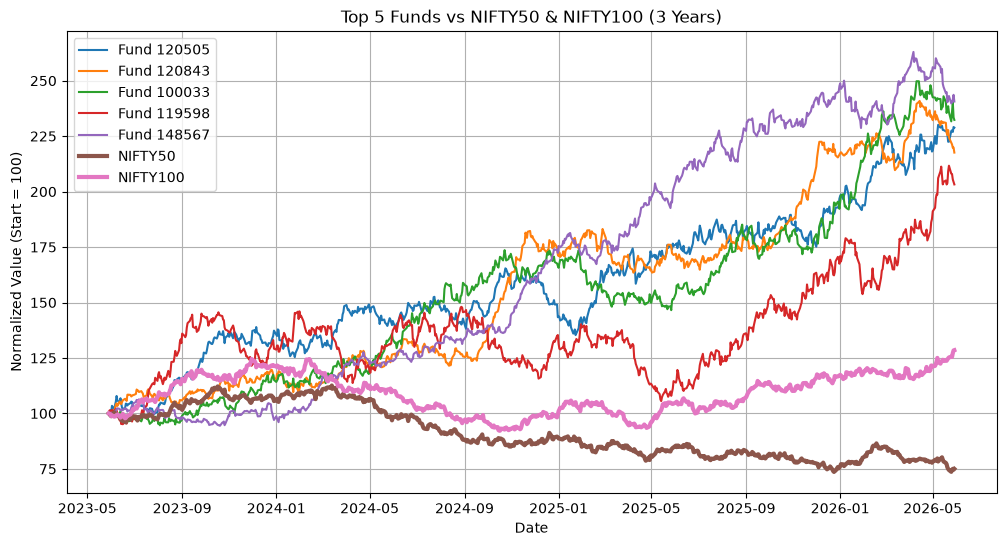

In [28]:
# Top 5 fund codes
top_codes = top5["amfi_code"].tolist()

# Filter NAV data
top_nav = nav_data[nav_data["amfi_code"].isin(top_codes)].copy()

# Keep last 3 years
latest_date = top_nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

top_nav = top_nav[top_nav["date"] >= start_date]

# Normalize each fund to start at 100
plt.figure(figsize=(12,6))

for code in top_codes:
    fund = top_nav[top_nav["amfi_code"] == code].sort_values("date")

    normalized = fund["nav"] / fund["nav"].iloc[0] * 100

    plt.plot(
        fund["date"],
        normalized,
        label=f"Fund {code}"
    )

# Plot NIFTY50 and NIFTY100
for index in ["NIFTY50", "NIFTY100"]:
    bench = benchmark[
        (benchmark["index_name"] == index) &
        (benchmark["date"] >= start_date)
    ].sort_values("date")

    normalized = bench["close_value"] / bench["close_value"].iloc[0] * 100

    plt.plot(
        bench["date"],
        normalized,
        linewidth=3,
        label=index
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../data/processed/benchmark_comparison_chart.png", dpi=300)

plt.show()

In [32]:
from scipy.stats import linregress

tracking_results = []

# Use NIFTY50 as benchmark
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

nifty50 = nifty50.sort_values("date")
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

for code in top_codes:

    fund = nav_data[nav_data["amfi_code"] == code].copy()

    fund = fund.sort_values("date")

    merged = pd.merge(
        fund,
        nifty50[["date", "benchmark_return"]],
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_results)

print(tracking_error_df)

   amfi_code  Tracking_Error
0     120505        0.233124
1     120843        0.205148
2     100033        0.229755
3     119598        0.278033
4     148567        0.193996


In [30]:
print(nav_data.columns) 

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [31]:
nav_data = nav_data.sort_values(["amfi_code", "date"])

nav_data["daily_return"] = (
    nav_data.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_data.head())
print(nav_data.columns)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [33]:
fund_scorecard = fund_scorecard.merge(
    tracking_error_df,
    on="amfi_code",
    how="left"
)

fund_scorecard.head()

,amfi_code,CAGR,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Maximum_Drawdown,return_3yr_pct,expense_ratio_pct,rank_3yr,...,rank_alpha,rank_expense,rank_drawdown,score_3yr,score_sharpe,score_alpha,score_expense,score_drawdown,Fund_Score,Tracking_Error
0,120505,0.328274,1.180101,2.029353,0.292636,0.000549,-0.181885,18.08,1.36,8.0,...,3.0,15.0,25.0,82.5,90.0,95.0,65.0,40.0,80.000,0.233124
1,120843,0.309075,1.306744,2.364320,0.273305,-0.022830,-0.129740,15.65,1.45,11.0,...,5.0,22.0,13.0,75.0,97.5,90.0,47.5,70.0,79.000,0.205148
2,100033,0.301232,1.093699,1.829134,0.271954,0.005104,-0.162172,16.58,1.38,10.0,...,6.0,17.0,20.0,77.5,85.0,87.5,60.0,52.5,76.250,0.229755
3,119598,0.324235,0.945308,1.675317,0.303370,-0.023196,-0.287060,23.39,1.43,1.0,...,1.0,21.0,36.0,100.0,67.5,100.0,50.0,12.5,75.625,0.278033
4,148567,0.309741,1.448291,2.385644,0.269838,0.023684,-0.112657,14.81,1.46,17.0,...,7.0,23.0,8.0,60.0,100.0,85.0,45.0,82.5,75.000,0.193996


In [34]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Final fund_scorecard.csv saved successfully!")

Final fund_scorecard.csv saved successfully!


In [35]:
plt.savefig(
    "../data/processed/benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

print("Benchmark chart saved!")

Benchmark chart saved!


<Figure size 640x480 with 0 Axes>